In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

output_dir = Path(os.environ.get("OUTPUT_DATA_DIR", "../output_data")).resolve()

df_per_subject = pd.read_csv(output_dir / "datasets_tidy_per_subject.csv")
df_total = pd.read_csv(output_dir / "datasets_tidy_total.csv")

pivot_per_subject = df_per_subject.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
pivot_total = df_total.pivot_table(index="dataset", columns="dotpath", values="value", aggfunc="first")
datasets_list = df_per_subject["dataset"].unique().tolist()

print(f"Loaded {len(datasets_list)} dataset(s)")

Loaded 8 dataset(s)


In [2]:
import sys
sys.path.insert(0, str(Path(__file__).resolve().parents[1])) if "__file__" in dir() else sys.path.insert(0, "../")
from analysis.visualisation import make_bubble_chart, make_legend
from analysis.tables import COLUMN_GROUPS_PER_SUBJECT, COLUMN_GROUPS_TOTAL

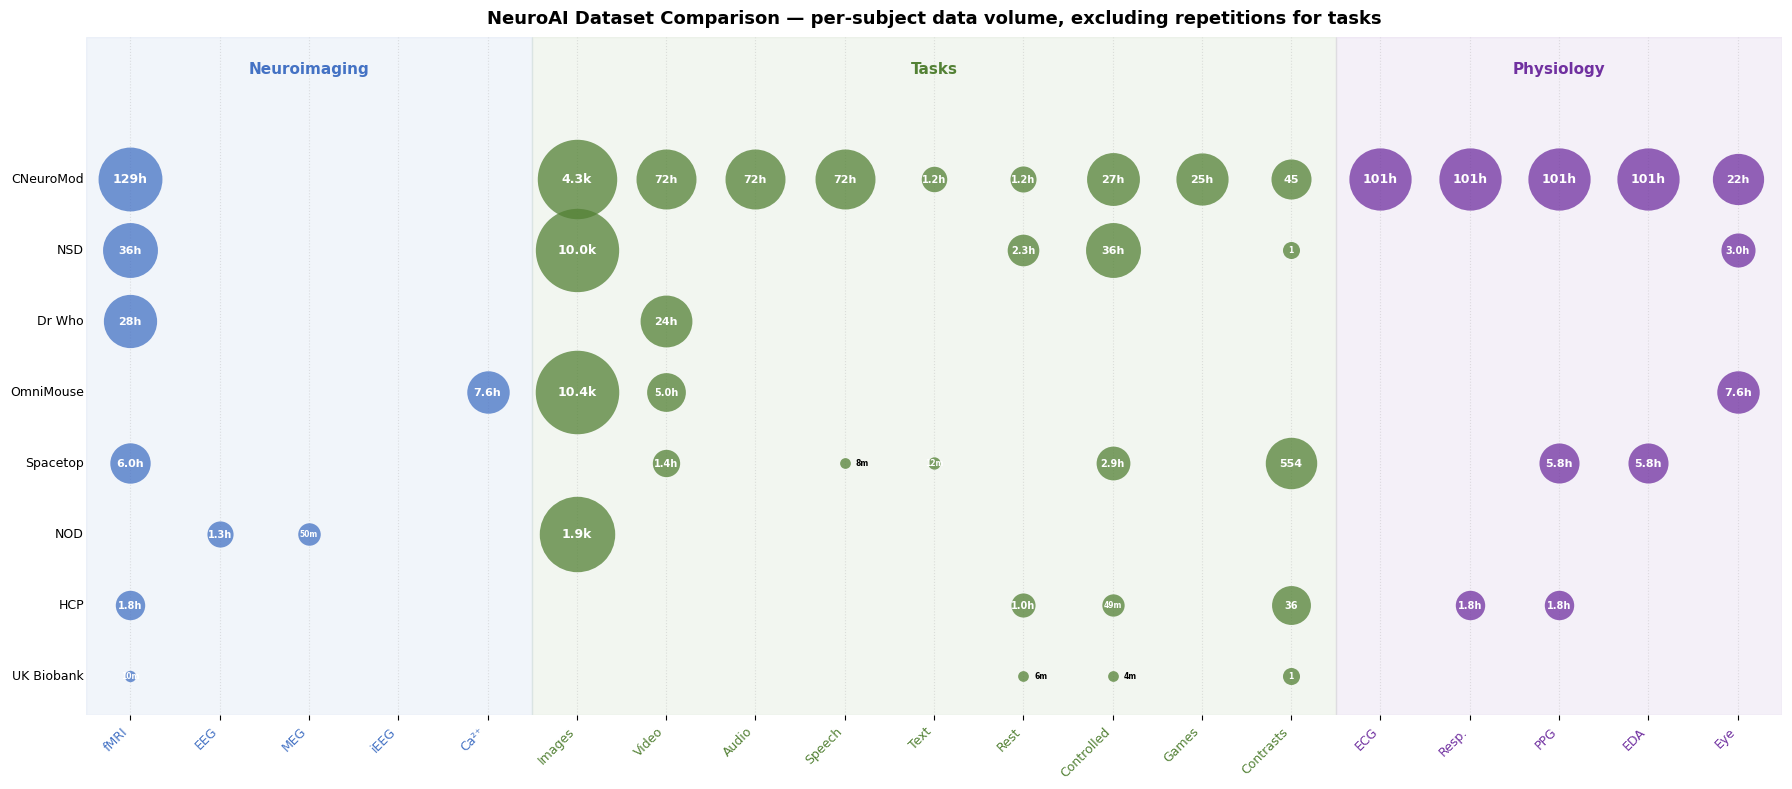

Saved dataset_comparison_per_subject.png


In [3]:
make_bubble_chart(
    COLUMN_GROUPS_PER_SUBJECT,
    pivot_per_subject,
    datasets_list,
    "NeuroAI Dataset Comparison — per-subject data volume, excluding repetitions for tasks",
    output_dir / "dataset_comparison_per_subject.png",
)

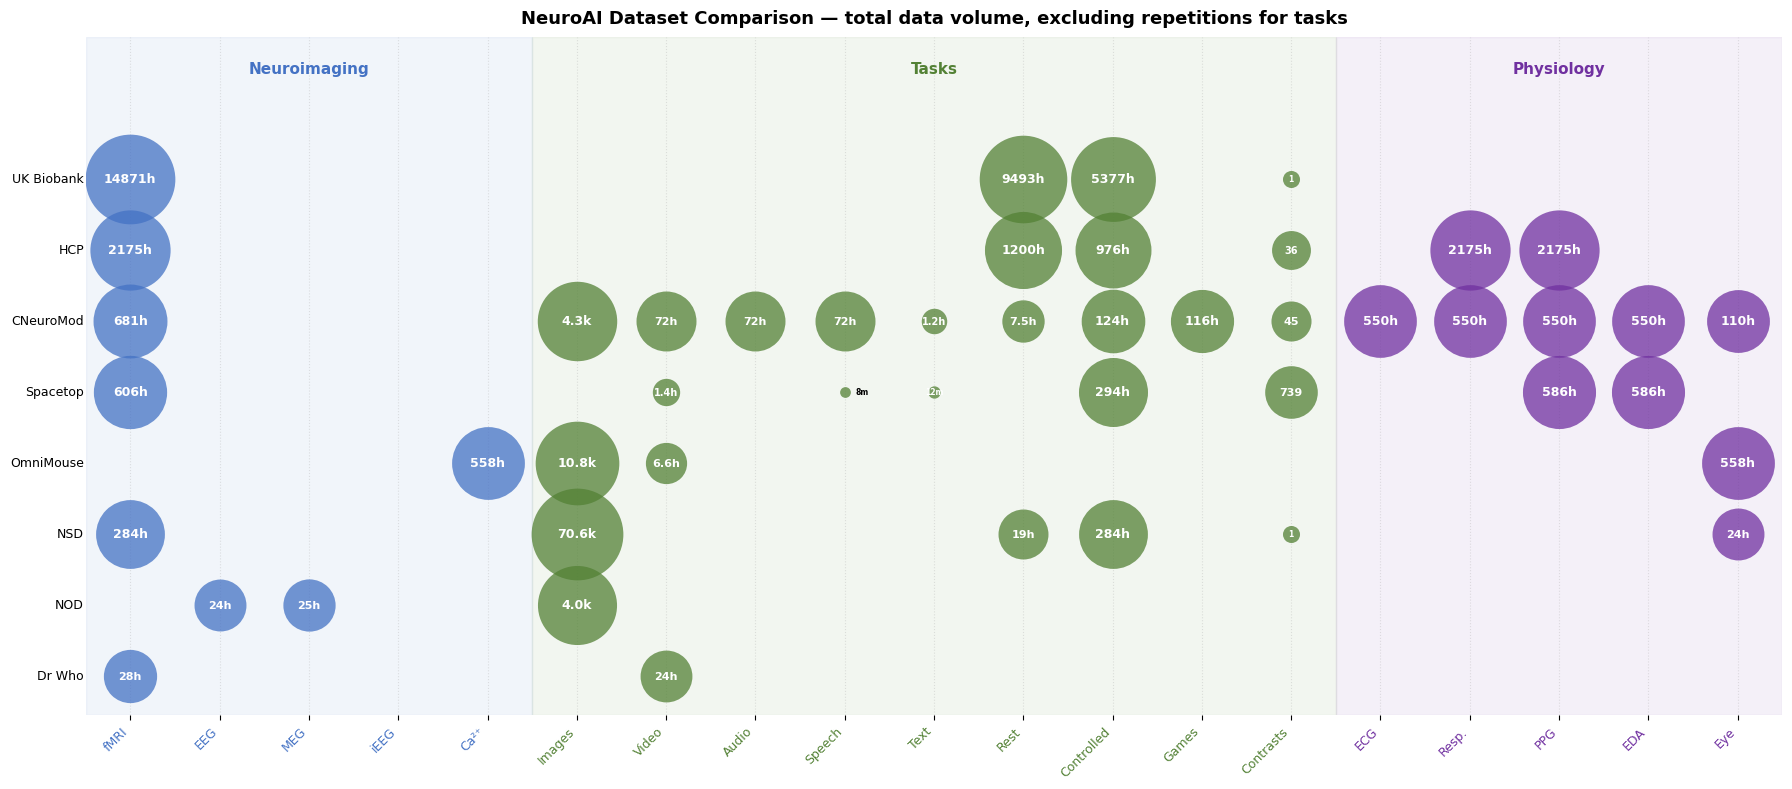

Saved dataset_comparison_total.png


In [4]:
make_bubble_chart(
    COLUMN_GROUPS_TOTAL,
    pivot_total,
    datasets_list,
    "NeuroAI Dataset Comparison — total data volume, excluding repetitions for tasks",
    output_dir / "dataset_comparison_total.png",
)

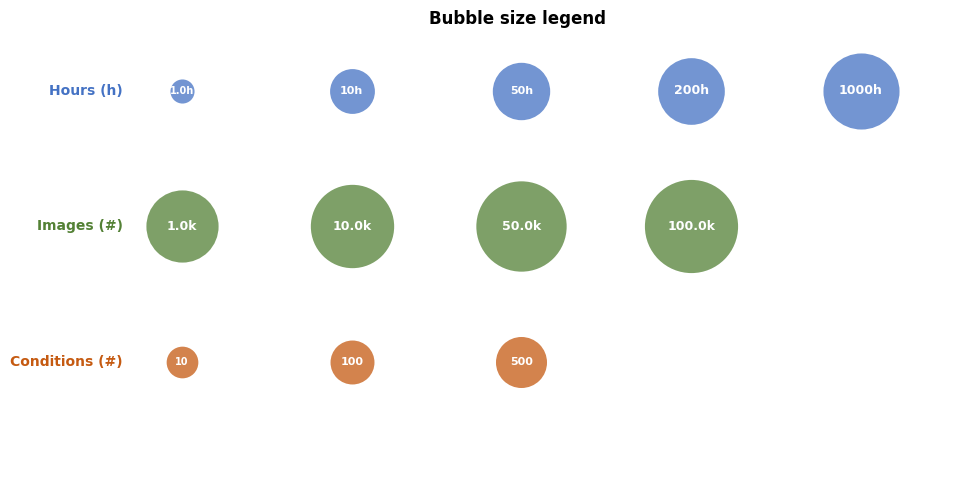

Saved dataset_comparison_legend.png


In [5]:
make_legend(output_dir / "dataset_comparison_legend.png")

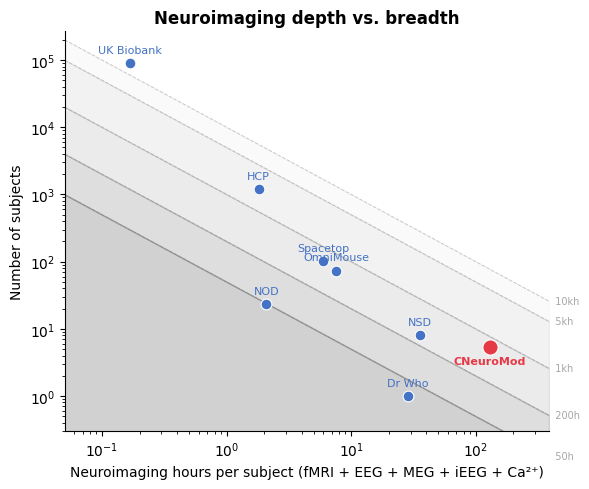

Saved dataset_neuroimaging_depthvsbreadth.png


In [6]:
from analysis.visualisation import make_neuroimaging_depthvsbreadth

make_neuroimaging_depthvsbreadth(
    pivot_per_subject,
    pivot_total,
    datasets_list,
    output_dir / "dataset_neuroimaging_depthvsbreadth.png",
    column_groups_per_subject=COLUMN_GROUPS_PER_SUBJECT,
    column_groups_total=COLUMN_GROUPS_TOTAL,
)